## Imports

In [130]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

from sklearn.model_selection import cross_validate, learning_curve, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Courbes d'Apprentissage


🎯 Cet exercice consiste à utiliser les Courbes d'Apprentissage pour diagnostiquer la performance d'un modèle en ce qui concerne le **biais** et la **variance**, ainsi qu'à repérer et corriger le **sous-apprentissage** et le **sur-apprentissage**.

❓ Chargez le jeu de données `NBA.csv` dans ce notebook en tant que dataframe pandas, et affichez ses 5 premières lignes.

In [131]:
df = pd.read_csv("../Data/NBA.csv")

In [132]:
df

,season,poss,mp,do_ratio,pacing,win_rating
0,1987,4847,2409,-1.546275,-0.599918,1.643091
1,2017,5582,2708,0.996587,0.531888,10.808427
2,2016,4976,2407,0.242598,0.127976,3.054773
3,2021,1178,585,-1.343806,-1.201034,0.230004
4,1988,4534,2056,-1.813990,-0.128997,0.905614
...,...,...,...,...,...,...
3995,1986,1224,565,-1.761425,-0.011698,0.082828
3996,1994,3564,1785,0.907199,-0.125856,3.542416
3997,1998,706,378,0.848178,0.694183,0.787185
3998,2003,289,156,-6.298906,0.205844,-0.312601


ℹ️ Vous pouvez lire une description détaillée du jeu de données dans le README du défi. Assurez-vous de vous y référer tout au long du défi.

## 1. Validation Croisée

❓ Validez de manière croisée un modèle de Régression Linéaire destiné à prédire la note de victoire des joueurs en fonction des minutes jouées (`mp`). Sauvegardez la moyenne des scores comme `cv_score`.

In [133]:
X = df[['mp']]
y = df['win_rating']

model = LinearRegression()

cv_score = cross_validate(model, X, y, cv=5)


In [134]:
cv_score['test_score'].mean()

0.556730180006891

## 2. Courbes d'Apprentissage

Les courbes d'apprentissage sont utilisées pour diagnostiquer la performance du modèle plus en profondeur.
 
❓ Tracez les courbes d'apprentissage du modèle ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.learning_curve.html)). 

Pour les tailles d'entraînement, vous devriez commencer avec **100** lignes et incrémenter de **100** jusqu'à ce que 80% du jeu de données soit utilisé pour l'entraînement (**3200**). Vous devriez donc finir avec **32** tranches. [np.arange](https://numpy.org/doc/stable/reference/generated/numpy.arange.html) peut aider!

In [135]:
train_sizes = np.arange(100, 3300, 100)
train_sizes

array([ 100,  200,  300,  400,  500,  600,  700,  800,  900, 1000, 1100,
       1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200,
       2300, 2400, 2500, 2600, 2700, 2800, 2900, 3000, 3100, 3200])

In [136]:
# Get train scores, train sizes, and validation scores using `learning_curve`, r2 score
train_sizes, train_scores, test_scores = learning_curve(
    estimator = LinearRegression(),
    X = X,
    y = y,
    train_sizes = train_sizes,
    cv = 5
)

train_sizes, train_scores, test_scores

(array([ 100,  200,  300,  400,  500,  600,  700,  800,  900, 1000, 1100,
        1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200,
        2300, 2400, 2500, 2600, 2700, 2800, 2900, 3000, 3100, 3200]),
 array([[0.56323124, 0.60687505, 0.60687505, 0.60687505, 0.60687505],
        [0.51934308, 0.58556283, 0.58556283, 0.58556283, 0.58556283],
        [0.52436751, 0.59659362, 0.59659362, 0.59659362, 0.59659362],
        [0.53562835, 0.53745643, 0.53745643, 0.53745643, 0.53745643],
        [0.55089343, 0.54670868, 0.54670868, 0.54670868, 0.54670868],
        [0.55188063, 0.55535708, 0.55535708, 0.55535708, 0.55535708],
        [0.55238745, 0.55793177, 0.55793177, 0.55793177, 0.55793177],
        [0.54699291, 0.55845952, 0.55845952, 0.55845952, 0.55845952],
        [0.55507741, 0.56476674, 0.55633862, 0.55633862, 0.55633862],
        [0.54972615, 0.55863434, 0.55186786, 0.55186786, 0.55186786],
        [0.548967  , 0.55662296, 0.54909786, 0.54909786, 0.54909786],
        [0.5

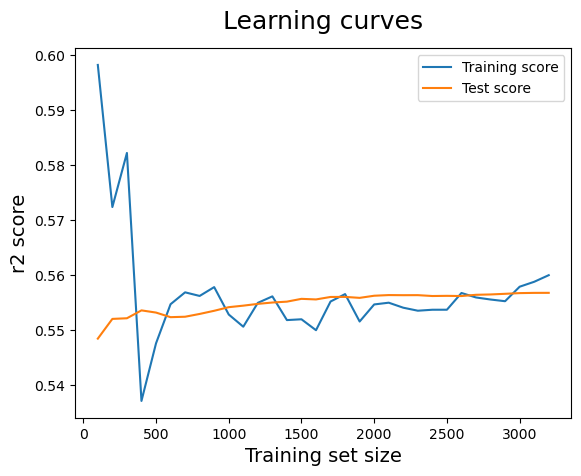

In [137]:
# Take the mean of cross-validated train scores and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_scores_mean, label = 'Training score')
plt.plot(train_sizes, test_scores_mean, label = 'Test score')
plt.ylabel('r2 score', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves', fontsize = 18, y = 1.03)
plt.legend()

❓ Comment interpréteriez-vous les courbes d'apprentissage?


<details>
<summary> ℹ️ Dépliez cette cellule pour voir notre interprétation </summary>   
    
<br/>
    
Nous observons un **sous-apprentissage**

👉 Les courbes devraient avoir convergé à un score bas (soyez conscient de l'échelle : parfois elles semblent éloignées, mais leur score est très proche! Vous pouvez essayer de changer <code>plt.ylim()</code> pour avoir une vue plus claire)
- Le score d'entraînement a considérablement diminué à mesure que la taille de l'ensemble d'entraînement a augmenté
- Le score de test n'a que très peu augmenté - moins de 1%! - même avec 80% du jeu de données utilisé pour l'entraînement.

👉 Il y a deux raisons typiques qui causent le sous-apprentissage:
- Le modèle est **trop simple** pour apprendre les modèles des données
- Le modèle a besoin de **plus de features** pour mieux prédire la note de victoire des joueurs
    
</details>


## 3. Ajout de features

Jusqu'à présent, comme nous l'avons vu, la performance du modèle ne semble pas optimale. Nous pouvons essayer de la corriger en ajoutant plus de features (caractéristiques) - utilisons celles que notre ami de la ligue fantasy NBA a suggérées!

❓ Validez de manière croisée un modèle destiné à prédire la note de victoire des joueurs avec:
- Minutes jouées (`mp`)
- Possessions (`poss`)
- Rapport défense/offense (`do_ratio`)
- Rythme

Enregistrez le nouveau score de validation croisée sous une variable nommée `score_added_features`.

In [138]:
mp = df[['mp']]
poss = df[['poss']]
do_ratio = df[['do_ratio']]

all_features = df[['mp', 'poss', 'do_ratio']]

model = LinearRegression()

cv_score = cross_validate(model, all_features, y, cv=5)
cv_score['test_score'].mean()

0.6323455037541358

ℹ️ La performance du modèle devrait avoir augmenté! L'ajout de features fournit au modèle des informations supplémentaires à partir desquelles apprendre et avec lesquelles modéliser le modèle des données.

## 4. Courbes d'Apprentissage 2

❓ Tracez les courbes d'apprentissage du nouveau modèle pour évaluer davantage sa performance (vous pouvez jouer avec [plt.ylim()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.ylim.html) pour rendre les courbes plus évidentes)

In [139]:
# Get train scores, train sizes, and validation scores using `learning_curve`, r2 score
train_sizes, train_scores, test_scores = learning_curve(
    estimator = LinearRegression(),
    X = X,
    y = y,
    train_sizes = train_sizes,
    cv = 5
)

train_sizes, train_scores, test_scores

(array([ 100,  200,  300,  400,  500,  600,  700,  800,  900, 1000, 1100,
        1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200,
        2300, 2400, 2500, 2600, 2700, 2800, 2900, 3000, 3100, 3200]),
 array([[0.56323124, 0.60687505, 0.60687505, 0.60687505, 0.60687505],
        [0.51934308, 0.58556283, 0.58556283, 0.58556283, 0.58556283],
        [0.52436751, 0.59659362, 0.59659362, 0.59659362, 0.59659362],
        [0.53562835, 0.53745643, 0.53745643, 0.53745643, 0.53745643],
        [0.55089343, 0.54670868, 0.54670868, 0.54670868, 0.54670868],
        [0.55188063, 0.55535708, 0.55535708, 0.55535708, 0.55535708],
        [0.55238745, 0.55793177, 0.55793177, 0.55793177, 0.55793177],
        [0.54699291, 0.55845952, 0.55845952, 0.55845952, 0.55845952],
        [0.55507741, 0.56476674, 0.55633862, 0.55633862, 0.55633862],
        [0.54972615, 0.55863434, 0.55186786, 0.55186786, 0.55186786],
        [0.548967  , 0.55662296, 0.54909786, 0.54909786, 0.54909786],
        [0.5

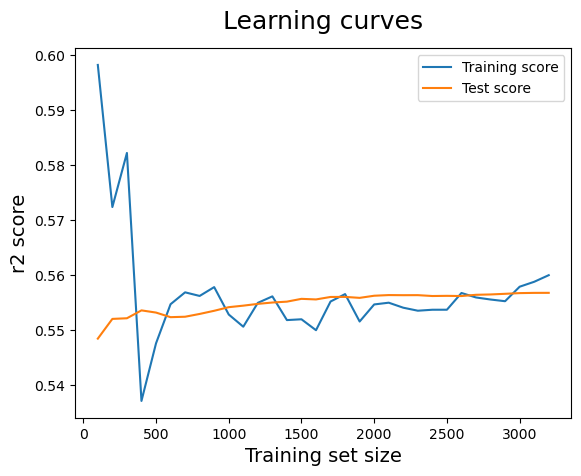

In [140]:
# Take the mean of cross-validated train scores and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_scores_mean, label = 'Training score')
plt.plot(train_sizes, test_scores_mean, label = 'Test score')
plt.ylabel('r2 score', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves', fontsize = 18, y = 1.03)
plt.legend()

❓ Comment interpréteriez-vous les courbes d'apprentissage?


<details>
<summary> ℹ️ Dépliez cette cellule pour voir notre interprétation </summary>   
    
<br/>
    
Il y a une amélioration, mais il semble toujours y avoir un certain **sous-apprentissage**

👉 Les courbes devraient avoir convergé, mais le score d'entraînement diminue encore sensiblement plus que le score de test n'augmente.

👉 L'ajout de plus de features a un peu aidé, mais n'a pas complètement résolu le problème de sous-apprentissage. Nous pouvons donc examiner l'autre cas typique:
- Le modèle est **trop simple** pour apprendre les modèles des données
    
</details>


## 5. Améliorer l'Ajustement du Modèle Linéaire avec des Features Polynomiales

Nous avons fait de notre mieux avec les features de notre jeu de données, mais nous voyons encore des signes de sous-apprentissage.

Il se pourrait que s'appuyer sur des combinaisons linéaires de features rende notre modèle **trop simple** pour la relation entre la note de victoire et les features des joueurs - nous pouvons essayer de résoudre cela avec un peu de **feature engineering**. 🛠️

🔍 La plupart de notre capacité à expliquer/prédire la note de victoire des joueurs provient de la feature des minutes jouées (`mp`). Examinons cette feature de plus près.

👇 Tracez un nuage de points de la relation entre ces deux colonnes. N'hésitez pas à utiliser seaborn ou matplotlib.

<Axes: xlabel='mp', ylabel='win_rating'>

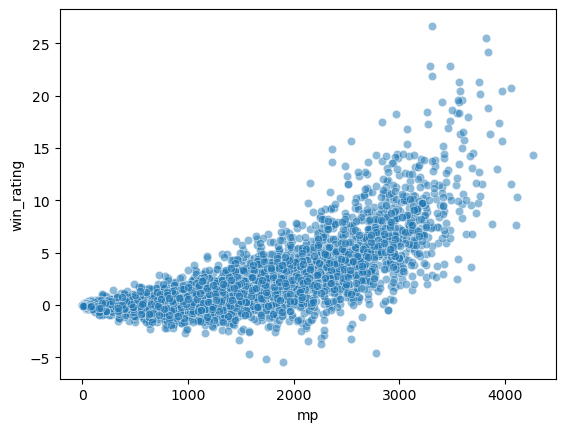

In [150]:
sns.scatterplot(df, x='mp', y='win_rating', alpha=0.5)

In [141]:
test_scores

array([[0.51142916, 0.53450961, 0.53707784, 0.57873   , 0.58029942],
       [0.53854555, 0.52786624, 0.53459206, 0.57911545, 0.57985595],
       [0.53101901, 0.53363356, 0.53682469, 0.57875543, 0.5803246 ],
       [0.53389206, 0.54170488, 0.53811488, 0.57573217, 0.57827408],
       [0.5433306 , 0.53202669, 0.53554201, 0.57622275, 0.57860556],
       [0.54216675, 0.52992501, 0.53478503, 0.57619655, 0.5784744 ],
       [0.54904857, 0.52805655, 0.53343765, 0.57441878, 0.57698182],
       [0.54460209, 0.53064351, 0.53495426, 0.57594981, 0.57832677],
       [0.54983196, 0.52804826, 0.53633155, 0.57519367, 0.57794687],
       [0.54900514, 0.53182253, 0.5366077 , 0.5752095 , 0.57798171],
       [0.5467365 , 0.5359271 , 0.53723698, 0.5745897 , 0.57752253],
       [0.55045295, 0.53363582, 0.53751087, 0.57454946, 0.57747097],
       [0.55126451, 0.53397756, 0.53742173, 0.57464094, 0.57755452],
       [0.55250062, 0.53351264, 0.53764655, 0.57454949, 0.57744864],
       [0.55171398, 0.53554457, 0.

🎯 Entraînons un modèle `LinearRegression` avec `mp` et `win_rating` avec une **mise de côté**.

👇 Traçons la ligne de régression apprise sur le même graphique pour voir à quel point elle s'adapte aux données. Rappelez-vous, vous pouvez extraire les coefficients d'un modèle linéaire entraîné avec `coef_` et `intercept_`

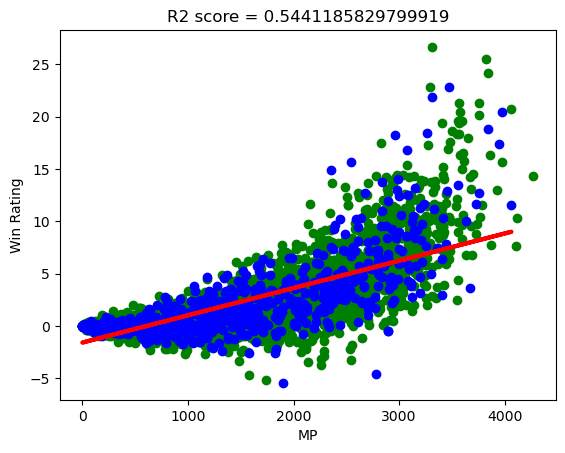

In [158]:
x = df[['mp']]
y = df[['win_rating']]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)
model.fit(X_train, y_train)

lin_reg_score = model.score(X_test, y_test)

regression = model.coef_[0] * x + model.intercept_

plt.scatter(X_train, y_train, color='green')
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, model.predict(X_test), color='red', linewidth=3)
plt.title('R2 score = {}'.format(lin_reg_score))
plt.xlabel('MP')
plt.ylabel('Win Rating')
plt.show()

❓ Voyez-vous ce qui pourrait causer le sous-apprentissage de notre modèle?


<details>
<summary> ℹ️ Dépliez cette cellule pour voir notre interprétation </summary>   
    
<br/>
    
Il semble que nous essayions d'ajuster une ligne droite apprise par le modèle de Régression Linéaire sur des données qui sont distribuées de manière *curvilinéaire*.
    
</details>


Nous pouvons essayer d'améliorer le modèle en ajoutant des [**features Polynomiales**](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html#sklearn.preprocessing.PolynomialFeatures) (PolynomialFeatures) .

Les features polynomiales sont des produits de features existantes d'un certain degré. Par exemple, si nous avons deux features - `a` et `b` - et que nous ajoutons des features polynomiales de degré 2, nous nous retrouverions avec un ensemble de features [`a`, `b`, `a`$^2$, `a` $*$ `b`, `b`$^2$].

Grâce aux exposants créés par `PolynomialFeatures` de sklearn, nous pouvons entraîner un modèle pour représenter de plus près les relations curvilinéaires, comme celle observée entre les notes de victoire des joueurs et les minutes jouées.

Essayons! 🚀

👇 Mettons à jour notre ensemble de features `X` avec des features polynomiales de degré 2. Vérifiez [l'exemple dans la documentation sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html#Examples:~:text=linear_model/plot_polynomial_interpolation.py-,Examples,-%3E%3E%3E) pour voir comment transformer les données - le premier exemple ci-dessous est fait par nous 😉

In [142]:
polynomial_features = PolynomialFeatures(degree=2, include_bias=False) # we don't want to add a column of 1's
X_poly = polynomial_features.fit_transform(X)

X_poly = pd.DataFrame(X_poly) # turning it back into a DataFrame for easier manipulation
X_poly.head()

,0,1
0,2409.0,5803281.0
1,2708.0,7333264.0
2,2407.0,5793649.0
3,585.0,342225.0
4,2056.0,4227136.0


☝️ Notez que les noms des colonnes ont disparu en raison de la transformation - n'hésitez pas à les mettre à jour, ou gardez simplement à l'esprit que la première colonne est notre `mp` original et la nouvelle colonne - `mp`$^2$.

🎯 Vérifions si l'ajout d'une feature polynomiale de `degré=2` aide le modèle à mieux représenter la relation entre les minutes jouées et la note de victoire d'un joueur.

👇 Exécutez la cellule ci-dessous pour voir la nouvelle ligne de régression, créée par un modèle entraîné sur des features polynomiales de degré 2, c'est-à-dire `mp` et `mp`$^2$. 

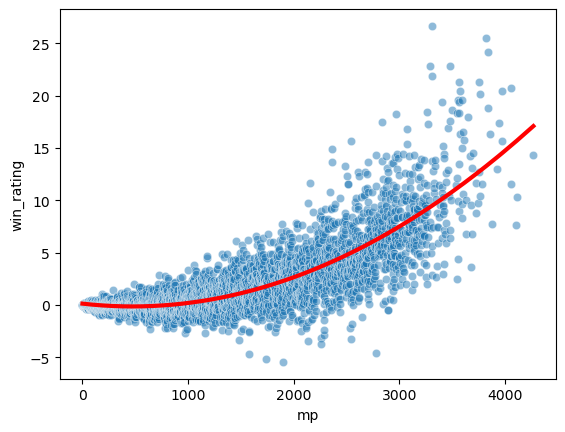

In [143]:
## Here, we sort out data so that when we plot our final
## line on our scatterpot it looks smooth.
## You won't need to do this later on in the exercise!

sorted_df = df.sort_values('mp')

X_sorted = sorted_df[['mp']]
y_sorted = sorted_df['win_rating']

#creating our polynomial features
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X_sorted)

#fit model
model.fit(X_poly, y_sorted)

predictions = model.predict(X_poly)

#plot predictions over original data
sns.scatterplot(x=X_sorted['mp'], y=y_sorted, alpha=0.5)
plt.plot(X_sorted['mp'], predictions, linewidth=3, color='r')

💡 La nouvelle ligne de régression semble mieux s'adapter à nos données - nous sommes sur la bonne voie!

## 6. Choisir le meilleur nombre de degrés

🔢 Revenons à notre **ensemble complet de features** - `['mp', 'poss', 'do_ratio', 'pacing']`


Nous avons vu que les Polynomial Features sur `mp` améliorent le modèle, mais qu'en est-il du reste du jeu de données ? 🤔

❓ Faites une validation croisée d'un modèle entraîné sur des polynomial features de `degree=2` de l'ensemble du jeu de données. Comment le score évolue-t-il par rapport aux modèles précédents ?

Le score du modèle devrait s'être considérablement amélioré ! Mais comment savoir si `degree=2` est le meilleur, et non 3, ou 5, ou 10... ? Donner à notre modèle plus de degrés de liberté devrait seulement améliorer le modèle, n'est-ce pas ? 🤔

❓ Effectuez une validation croisée avec des polynomial features de `degree` allant de **1** à **10**. Enregistrez tous les scores, puis tracez-les avec leurs degrés respectifs pour identifier le meilleur résultat.

🕰️ **NOTE :** l'exécution de la boucle complète prendra un certain temps, car un nombre plus élevé de degrés polynomiaux crée exponentiellement plus de features. 

❓ Pendant l'exécution, réfléchissez au nombre total de features que votre jeu de données aura avec `degree=10` ?

</br>

<details>
<summary> 🆘 Cliquez ici pour la réponse </summary>   

Pour chaque feature, vous créerez 10 nouvelles features de puissances différentes, ce qui fait déjà **44** features. Ensuite, les produits de toutes les combinaisons possibles de features sont ajoutés - ce qui donne **1000** features.
    
</details>

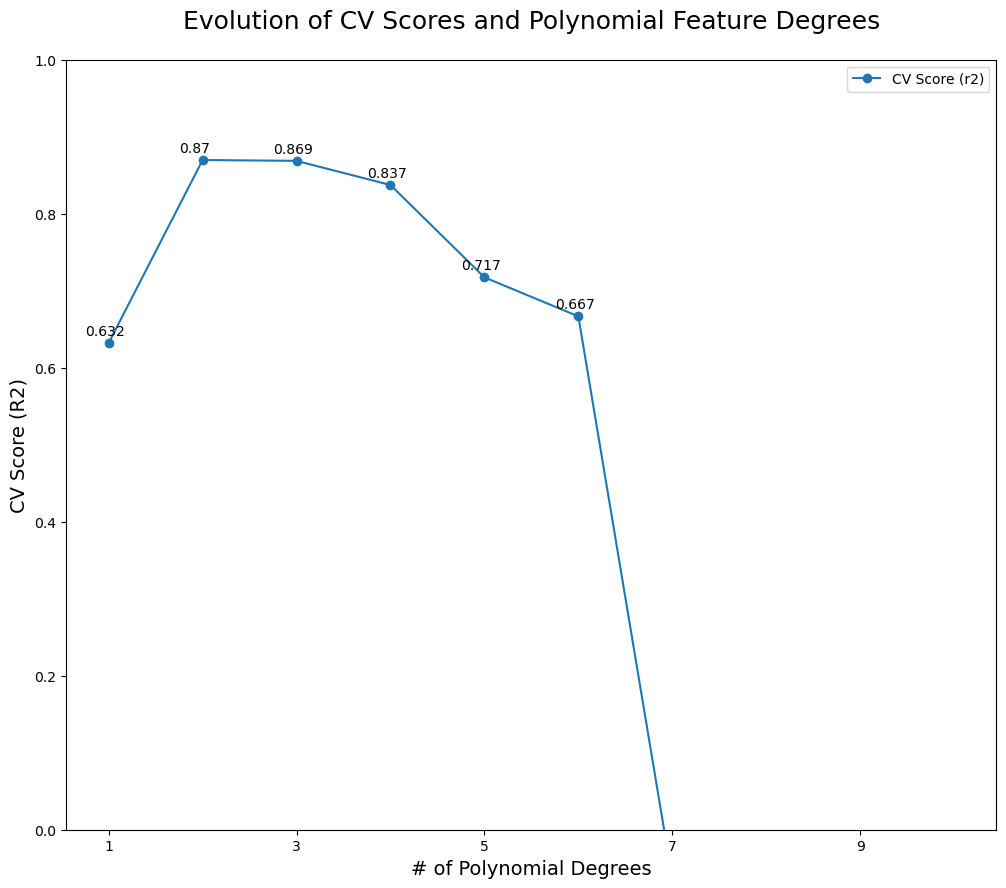

In [144]:
X = df[['mp', 'poss', 'do_ratio', 'pacing']]
y = df['win_rating']

degrees = list(range(1,11))

scores = []

for i in degrees:

    polynomial_features = PolynomialFeatures(degree=i, include_bias=False)
    X_poly = polynomial_features.fit_transform(pd.DataFrame(X))
    model = LinearRegression()

    cv_results = cross_validate(model, X_poly, y, cv=5)

    scores.append(cv_results['test_score'].mean())

# plotting the scores against degrees
plt.figure(figsize=(12, 10))
plt.plot(degrees, scores, label='CV Score (r2)', marker='o')

# annotating each marker with the score
for index, degree in enumerate(degrees):
    plt.annotate(round(scores[index], 3), (degree-0.25, scores[index]+0.01))

# fixing the ticks so they are not displayed as floats
plt.xticks(degrees[::2])

# adding titles and labels to the plot
plt.ylabel('CV Score (R2)', fontsize = 14)
plt.xlabel('# of Polynomial Degrees', fontsize = 14)
plt.title('Evolution of CV Scores and Polynomial Feature Degrees', fontsize = 18, y = 1.03)

plt.ylim(0,1)
plt.legend();

❓ Quel degré de polynomial feature est le mieux adapté pour prédire le win rating des joueurs NBA ?

<br/>

<details>
<summary> ℹ️ Cliquez ici pour valider votre réponse </summary>   
    
☝️ Vous devriez pouvoir constater que `degree=2` nous donne effectivement le meilleur score - maintenant jusqu'à **0.87** après avoir réintégré le reste des features !
    
</details>

😱 Mais que se passe-t-il après `degree=5` - avec *encore plus* d'informations, les résultats du modèle commencent à baisser ??

👇 Tracez les courbes d'apprentissage d'un modèle avec des polynomial features de `degree=5` pour essayer d'identifier le problème.

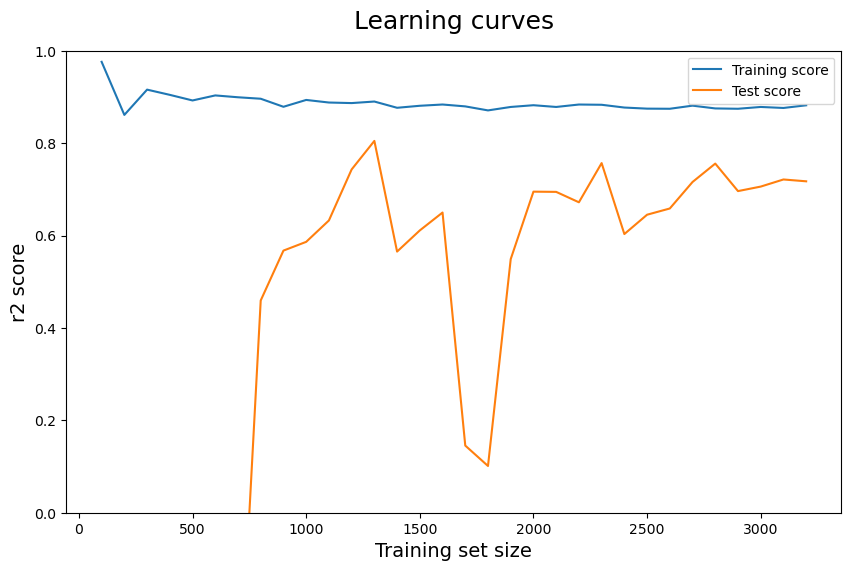

In [145]:
# Transform our X to include polynomial features
poly_features = PolynomialFeatures(degree=5, include_bias=False)
X_poly = poly_features.fit_transform(X)

# Get train scores, train sizes, and validation scores using `learning_curve`, r2 score
train_sizes, train_scores, test_scores = learning_curve(
    estimator = LinearRegression(),
    X = X_poly,
    y = y,
    train_sizes = train_sizes,
    cv = 5
)

# Take the mean of cross-validated train scores and test scores
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

# Plot the learning curves!
plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_scores_mean, label = 'Training score')
plt.plot(train_sizes, test_scores_mean, label = 'Test score')
plt.ylabel('r2 score', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves', fontsize = 18, y = 1.03)
plt.ylim(0,1)
plt.legend();

❓ Comment interpréteriez-vous ces courbes d'apprentissage ?


<details>
<summary> ℹ️ Dépliez cette cellule pour voir notre interprétation </summary>   
    
<br/>
    
Nous constatons un **surapprentissage** évident !
    
👉 Les courbes ne convergent pas, le modèle surajuste les données d'entraînement avec un score d'entraînement (`~0.9`) qui reste sensiblement plus élevé que le score de test (`~0.7`).
    
👉 En ajoutant des polynomial features de degré 5, il semble y avoir trop de "bruit" auquel le modèle prête attention et les coefficients appris ne représentent plus la réalité.
    
</details>

## 7. Réduire la taille de l'ensemble d'entraînement

🎯 Maintenant que nous avons trouvé le meilleur score de modèle possible, voyons si nous pouvons nous permettre d'entraîner le modèle sur moins de données pour économiser des ressources de calcul.

👇 Traçons les courbes d'apprentissage de notre meilleur modèle - toutes les features avec des polynomial features de `degree=2`.

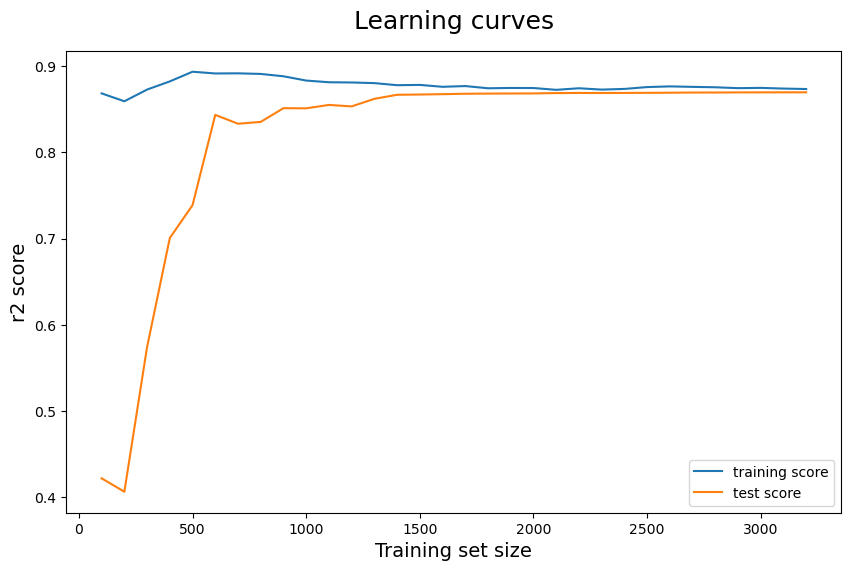

In [146]:
# create the training size slices
train_sizes = np.linspace(100, 3200, 32, dtype='int')

X_poly = PolynomialFeatures(degree=2, include_bias=False).fit_transform(X)

# Get train scores, train sizes, and validation scores using `learning_curve`, r2 score
train_sizes, train_scores, test_scores = learning_curve(
    estimator = LinearRegression(),
    X = X_poly,
    y = y,
    train_sizes = train_sizes,
    cv = 5
)

# Take the mean of cross-validated train scores and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

# Plot the learning curves!
plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_scores_mean, label = 'training score')
plt.plot(train_sizes, test_scores_mean, label = 'test score')
plt.ylabel('r2 score', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves', fontsize = 18, y = 1.03)
plt.legend()

❓ En regardant les nouvelles courbes d'apprentissage, combien d'exemples d'entraînement sont suffisants pour que le modèle apprenne les modèles du jeu de données ?

👇 Exécutez la cellule ci-dessous après avoir trouvé la réponse pour vérifier

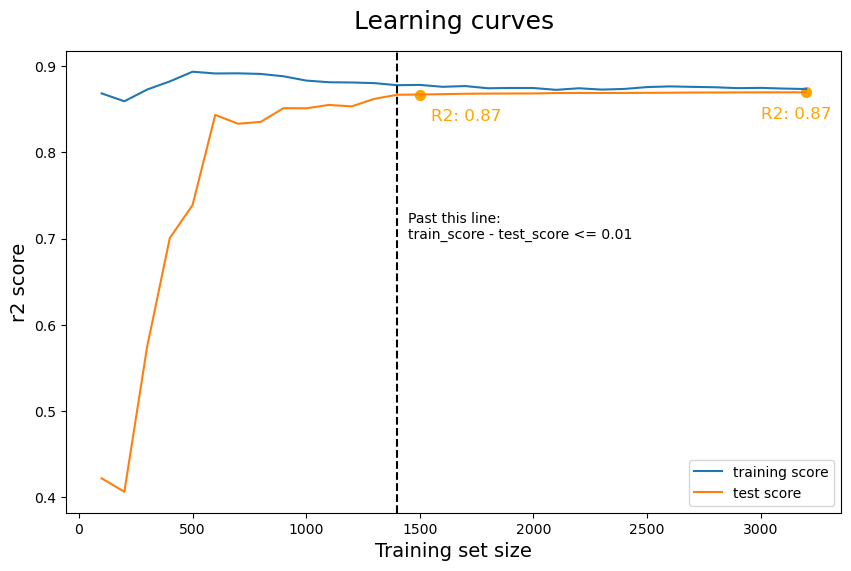

In [147]:
# Plotting the learning curves
plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_scores_mean, label = 'training score')
plt.plot(train_sizes, test_scores_mean, label = 'test score')
plt.ylabel('r2 score', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves', fontsize = 18, y = 1.03)

# Plotting a line where difference of train and test score becomes <1%
plt.axvline(1400, linestyle='--', c='black')
plt.annotate('Past this line:\ntrain_score - test_score <= 0.01', xy=(1450, 0.7))


# Comparing test scores at that line and at max training data (80% of data)
plt.scatter(train_sizes[14], test_scores_mean[14], c='orange', s=50)
plt.annotate(
    f"R2: {round(test_scores_mean[14], 2)}",
    xy=(train_sizes[14] + 50, test_scores_mean[14] - 0.03),
    fontsize=12, c='orange'
)

plt.scatter(train_sizes[31], test_scores_mean[31], c='orange', s=50)
plt.annotate(
    f"R2: {round(test_scores_mean[31],2)}",
    xy=(train_sizes[31] - 200, test_scores_mean[31] - 0.03),
    fontsize=12, c='orange'
)


plt.legend();

ℹ️ Plus il y a de données, plus l'entraînement est long. Dans certains cas, vous travaillerez avec d'énormes jeux de données. Dans ces situations, les courbes d'apprentissage peuvent vous aider à trouver le bon compromis entre la réduction de la taille d'entraînement (et du temps d'entraînement !) tout en maintenant un modèle performant.

Le score à `train_size=1500` est presque le même qu'avec l'ensemble complet du jeu de données ! D'autre part, vous auriez pu réduire les coûts de calcul - imaginez économiser 60% d'un jeu de données de 1 To !

## 8. Comparer les prédictions du modèle

👇 Nous avons vu l'évolution du score $R^2$ de nos modèles, mais voyons **à quel point les modèles prédisent avec précision**.

❓ Calculez le MSE - *Mean Squared Error* (la moyenne des carrés de `prédictions - cibles`) - pour deux modèles entraînés sur l'ensemble **complet** du jeu de données :

1. Un modèle entraîné sur toutes les features - `mp`, `poss`, pacing et le ratio défense/attaque d'un joueur
2. Un modèle entraîné avec des polynomial features de `degree=2`

❓ Enregistrez les MSE résultants dans des variables appelées respectivement `reg_score` et `poly_score`

In [175]:
# Get train scores, train sizes, and validation scores using `learning_curve`, r2 score
train_sizes, train_scores, test_scores = learning_curve(
    estimator = LinearRegression(),
    X = X_poly,
    y = y,
    train_sizes = train_sizes,
    cv = 5
)

### 1st Model ###
win_rating = df[['win_rating']]
X = df[['mp','poss','do_ratio','pacing']]

model = LinearRegression()

cv_score = cross_validate(model, X=X, y=win_rating, cv=5)
cv_score['test_score'].mean()
print("1st Model",cv_score['test_score'].mean())

### 2nd Model ###
polynomial_features = PolynomialFeatures(degree=2)
X_poly = polynomial_features.fit_transform(X)
model = LinearRegression()
cv_score = cross_validate(model, X=X_poly, y=win_rating, cv=5)
cv_score['test_score'].mean()
print("2nd Model",cv_score['test_score'].mean())


1st Model 0.6321354129549309
2nd Model 0.8697420123127063


❓ Qu'observez-vous en comparant les deux scores ?

# 🏁 Vous l'avez fait !
Non seulement vous avez pratiqué (beaucoup) de courbes d'apprentissage, mais, avec `PolynomialFeatures` de sklearn, vous avez utilisé votre premier *preprocessing transformer* - qui est le sujet du prochain cours !